<img src="https://data-analytics-fullstack-assets.s3.eu-west-3.amazonaws.com/M05-Python_Programming/M2_D4_Vector.png"/>

# Employee Analytics at Vector 📊

You work as a data analyst at **Vector**, a company that helps organizations understand their workforce through data. The people operations team collects metrics on heights, performance, salaries, and survey responses. They need you to use the four distributions from the lecture to model these metrics and answer concrete business questions.

## Setup

### Instructions

In the next code cell:

1. Import `numpy` as `np`.
2. From `scipy.stats`, import the four distribution objects you will use in this notebook: `from scipy.stats import binom, norm, expon, poisson`. Each object has methods like `.pmf`, `.pdf`, and `.cdf` for that specific distribution.
3. Import `matplotlib.pyplot` as `plt` and `seaborn` as `sns`.
4. Set the seaborn theme: `sns.set_theme(style="whitegrid")`.
5. Fix the random seed for reproducibility: `np.random.seed(42)`. Every random draw later in the notebook will produce the same numbers each time you run it.

<Note type='tip'>
**Why seed the random number generator?** Without `np.random.seed(...)`, every run of the notebook produces different numbers, and your printed counts and percentages will not match the expected values in the task descriptions. Seeding once at the top is the standard pattern for reproducible analysis.
</Note>


In [1]:
import numpy as np
from scipy.stats import binom, norm, expon, poisson
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Task 1: Model job offer acceptances with the binomial distribution

The recruiting team sends 10 job offers each week. Past data shows that each candidate accepts with probability 0.6, and acceptances are independent. The VP wants to know how many offers the team should expect to convert each week, and how rare a bad week of only 3 acceptances would be.

### Instructions

This task uses **two code cells**.

**First code cell**, parameters and a single probability:

1. Define the binomial parameters: `n_offers = 10` and `p_accept = 0.6`.
2. Compute the expected value with the formula `E[X] = n * p`: `expected_value = n_offers * p_accept`.
3. Compute the variance with `Var(X) = n * p * (1 - p)`: `variance = n_offers * p_accept * (1 - p_accept)`.
4. Print both numbers, for example `print(f"Expected acceptances per week (E[X]): {expected_value}")`.
5. Compute the probability of exactly 3 acceptances using `binom.pmf(k, n, p)`:
   ```python
   prob_three = binom.pmf(3, n_offers, p_accept)
   ```
6. Print it with four decimal places: `print(f"\nP(X = 3) = {prob_three:.4f}")`.

**Second code cell**, the full PMF as a bar chart:

1. Build an array of all possible counts from 0 to `n` inclusive: `k_values = np.arange(0, n_offers + 1)`. The `+ 1` is needed because `np.arange` excludes the endpoint.
2. Compute the probability for each value at once: `pmf_values = binom.pmf(k_values, n_offers, p_accept)`. SciPy's `pmf` accepts an array and returns one probability per element.
3. Open a figure: `fig, ax = plt.subplots(figsize=(10, 5))`.
4. Draw the bar chart: `sns.barplot(x=k_values, y=pmf_values, color="#FE0162", alpha=0.7, ax=ax)`.
5. Add a dashed vertical line at the expected value: `ax.axvline(expected_value, color="#0B155B", linestyle="--", linewidth=2)`.
6. Add a label above the line: `ax.text(expected_value, max(pmf_values) * 1.02, f"E[X] = {expected_value}", color="#0B155B", ha="center", fontweight="bold")`. The `ha="center"` argument centers the text horizontally on the line.
7. Set the title and axis labels with `ax.set_title(...)`, `ax.set_xlabel("Number of acceptances (k)")`, `ax.set_ylabel("Probability P(X = k)")`.
8. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**`pmf` vs `pdf`.** Discrete distributions (binomial, Poisson) use `pmf` (probability mass function): the probability of an exact integer outcome. Continuous distributions (normal, exponential) use `pdf` (probability density function): a density that integrates to a probability over an interval. Mixing them up gives nonsense values.
</Note>


In [2]:
# Your code here
n_offers = 10
p_accept = 0.6

expected_value = n_offers * p_accept
variance = n_offers * p_accept * (1 - p_accept)
print("Expected acceptances per week (E[X]):", expected_value)

prob_three = binom.pmf(3, n_offers, p_accept)

print(f"Probability of exactly 3 acceptances (P[X=3]): {prob_three:.4f}")

Expected acceptances per week (E[X]): 6.0
Probability of exactly 3 acceptances (P[X=3]): 0.0425


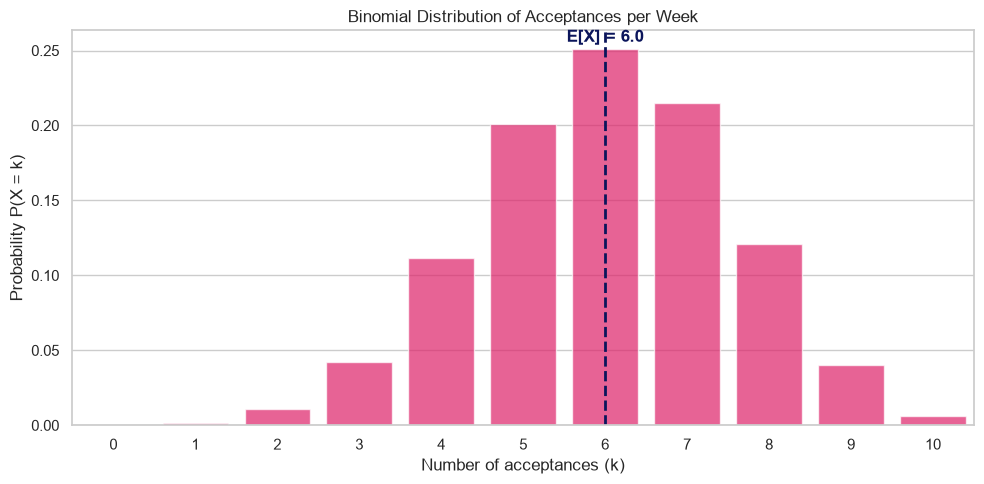

In [3]:
# Your code here
k_values = np.arange(0, n_offers + 1)
probabilities = binom.pmf(k_values, n_offers, p_accept)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=k_values, y=probabilities, color="#FE0162", alpha=0.7, ax=ax)

ax.axvline(expected_value, color="#0B155B", linestyle="--", linewidth=2)

ax.text(expected_value, max(probabilities) * 1.02, f"E[X] = {expected_value}", color="#0B155B", ha="center", fontweight="bold")

ax.set_title("Binomial Distribution of Acceptances per Week")
ax.set_xlabel("Number of acceptances (k)"), ax.set_ylabel("Probability P(X = k)")
plt.tight_layout()
plt.show()

## Task 2: Apply the 68-95-99.7 rule to employee heights

The health and wellness team designs ergonomic workstations. Employee heights follow a normal distribution with mean 170 cm and standard deviation 10 cm. The team wants to verify the empirical rule on real-looking data before they trust it for design choices.

### Instructions

This task uses **two code cells**.

**First code cell**, generate the data and check the three percentages:

1. Define the parameters: `mu_height = 170`, `sigma_height = 10`, `n_employees = 10000`.
2. Generate the heights: `heights = np.random.normal(loc=mu_height, scale=sigma_height, size=n_employees)`. The `loc` is the mean, the `scale` is the standard deviation.
3. Build six boundaries, one per side, for each multiple of sigma:
   - `low_1sigma = mu_height - sigma_height` and `high_1sigma = mu_height + sigma_height`.
   - `low_2sigma = mu_height - 2 * sigma_height` and `high_2sigma = mu_height + 2 * sigma_height`.
   - `low_3sigma = mu_height - 3 * sigma_height` and `high_3sigma = mu_height + 3 * sigma_height`.
4. Build a boolean mask for each interval. Use parentheses around each side of the comparison so Python applies `&` correctly:
   - `mask_1sigma = (heights >= low_1sigma) & (heights <= high_1sigma)`.
   - Repeat for the 2-sigma and 3-sigma masks.
5. A boolean array's `.mean()` returns the fraction of `True` values. Multiply by 100 to get a percentage:
   - `pct_1sigma = mask_1sigma.mean() * 100`.
   - Same for the 2-sigma and 3-sigma percentages.
6. Print the three percentages next to the theoretical values, for example: `print(f"Within 1 sigma ({low_1sigma}-{high_1sigma} cm): {pct_1sigma:.2f}%  (theory: 68%)")`.

**Second code cell**, the histogram with the theoretical curve overlay:

1. Open a figure: `fig, ax = plt.subplots(figsize=(10, 5))`.
2. Draw the density histogram: `sns.histplot(x=heights, bins=40, stat="density", color="#FE0162", alpha=0.6, ax=ax)`. Setting `stat="density"` rescales the y-axis so the area under the histogram equals 1, which is what makes a PDF curve overlay meaningful.
3. Build the points of the theoretical normal curve. Pick a fine x-grid spanning the data range, then evaluate the PDF at each point:
   - `x_curve = np.linspace(130, 210, 200)` builds 200 evenly spaced x-values from 130 to 210.
   - `y_curve = norm.pdf(x_curve, loc=mu_height, scale=sigma_height)` evaluates the normal PDF at each x.
4. Plot the curve on top: `ax.plot(x_curve, y_curve, color="#0B155B", linewidth=3, label="Theoretical N(170, 10^2)")`.
5. Add a dashed vertical line at the mean: `ax.axvline(mu_height, color="#0B155B", linestyle="--", linewidth=2)`.
6. Set the title and axis labels (`Height (cm)`, `Density`). Call `ax.legend()` so the curve label appears.
7. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**`stat="density"` is what makes the overlay work.** A default seaborn histogram shows counts, which depend on the bin width and the sample size. The theoretical PDF lives on a different scale entirely. Setting `stat="density"` puts both on the same y-axis so the overlay is meaningful.
</Note>


In [ ]:
# Your code here

Within 1 sigma (160-180 cm): 68.20%  (theory: 68%)
Within 2 sigma (150-190 cm): 95.33%  (theory: 95%)
Within 3 sigma (140-200 cm): 99.72%  (theory: 99.7%)


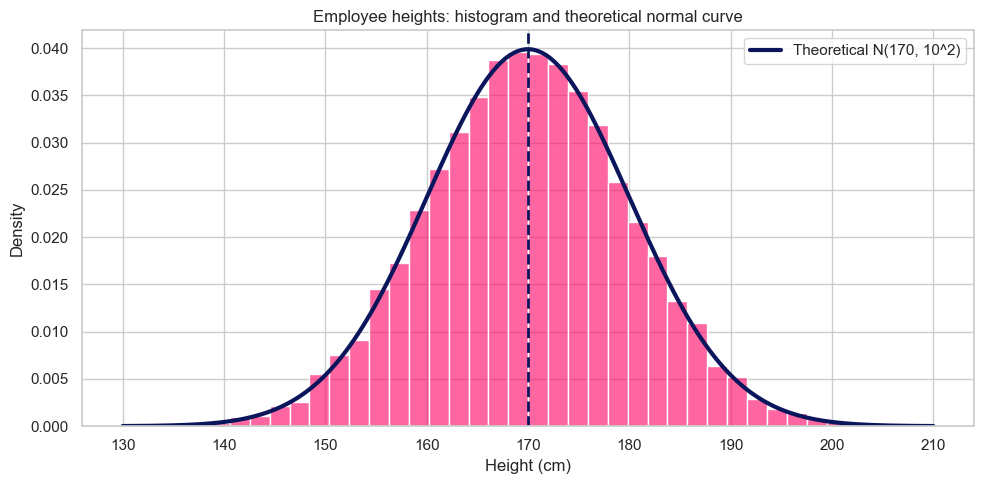

In [ ]:
# Your code here

## Task 3: Flag unusual performance scores with the 3-sigma rule

The performance team scores each employee on a 0 to 100 scale. Scores follow a normal distribution with mean 75 and standard deviation 12. The team wants a simple rule to flag scores worth a manager review.

### Instructions

This task uses **two code cells**.

**First code cell**, generate scores and count flags on each side:

1. Define the parameters: `mu_score = 75`, `sigma_score = 12`, `n_scores = 1000`.
2. Generate the scores: `scores = np.random.normal(loc=mu_score, scale=sigma_score, size=n_scores)`.
3. Build the bounds:
   - `lower_bound = mu_score - 3 * sigma_score`.
   - `upper_bound = mu_score + 3 * sigma_score`.
4. Print the two bounds.
5. Count flagged scores on each side. The `.sum()` method on a boolean array counts the `True` values:
   - `below_count = (scores < lower_bound).sum()`.
   - `above_count = (scores > upper_bound).sum()`.
   - `total_flagged = below_count + above_count`.
6. Print the three counts. Include the total out of `n_scores`, for example: `print(f"Total flagged              : {total_flagged} out of {n_scores}")`.

**Second code cell**, the histogram with three reference lines:

1. Open a figure: `fig, ax = plt.subplots(figsize=(10, 5))`.
2. Draw the histogram: `sns.histplot(x=scores, bins=40, color="#FE0162", alpha=0.7, ax=ax)`.
3. Add the **mean** line in dark blue, with a label centered horizontally:
   - `ax.axvline(mu_score, color="#0B155B", linestyle="--", linewidth=2)`.
   - `ax.text(mu_score, 1, f"Mean = {mu_score}", color="#0B155B", ha="center")`.
4. Add the **lower bound** line in red, with the same pattern:
   - `ax.axvline(lower_bound, color="red", linestyle="--", linewidth=2)`.
   - `ax.text(lower_bound, 1, f"-3 sigma = {lower_bound}", color="red", ha="center")`.
5. Add the **upper bound** line in red:
   - `ax.axvline(upper_bound, color="red", linestyle="--", linewidth=2)`.
   - `ax.text(upper_bound, 1, f"+3 sigma = {upper_bound}", color="red", ha="center")`.
6. Set the title and the axis labels (`Performance score`, `Number of employees`).
7. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**Counting with `.sum()` on booleans.** In NumPy, `True` is treated as 1 and `False` as 0 in arithmetic. So `(scores < lower_bound).sum()` is just a clean way to count how many entries satisfy the condition. The same pattern works on pandas Series.
</Note>


In [ ]:
# Your code here

Lower bound: 39
Upper bound: 111

Scores below 39: 2
Scores above 111: 0
Total flagged              : 2 out of 1000


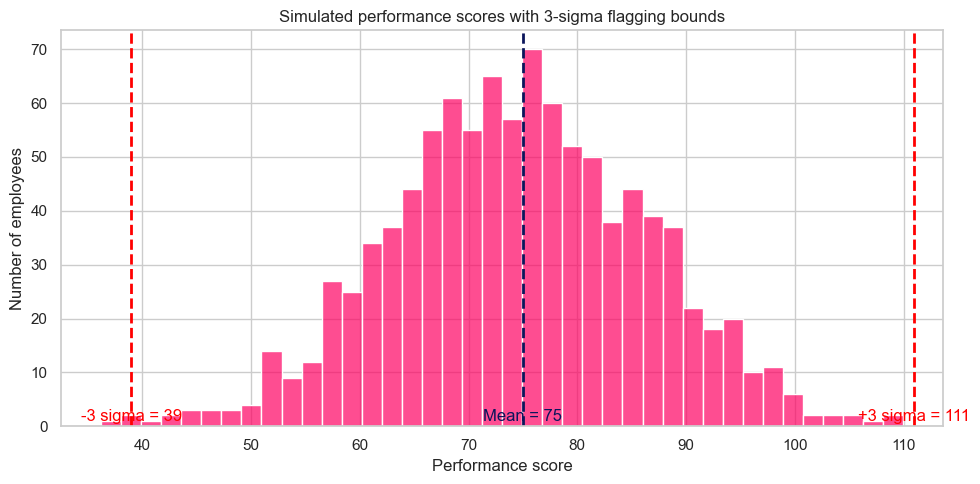

In [ ]:
# Your code here

## Task 4: Model time between sign-ups with the exponential distribution

Vector runs a self-service sign-up page. During peak hours, the time in minutes between two consecutive sign-ups follows an exponential distribution with mean 4 minutes. The infrastructure team needs to plan capacity, so they want to see the shape of this waiting time and confirm that the mean and the median differ.

### Instructions

This task uses **two code cells**.

**First code cell**, generate data and compute summary statistics:

1. Define the parameters: `scale_param = 4` (this is the mean of the exponential distribution) and `n_waits = 1000`.
2. Generate the waiting times: `wait_times = np.random.exponential(scale=scale_param, size=n_waits)`.
3. Compute three sample statistics:
   - `wait_mean = wait_times.mean()`.
   - `wait_median = np.median(wait_times)`. NumPy arrays do not have a `.median()` method, so use the function `np.median(...)`.
   - `wait_std = wait_times.std()`.
4. Print the three values with two decimal places. Include the theoretical mean for comparison: `print(f"Sample mean   : {wait_mean:.2f} minutes  (theory: {scale_param})")`.
5. Compute and print the gap between the mean and the median: `gap = wait_mean - wait_median`, then `print(f"\nGap (mean - median): {gap:.2f} minutes")`.

**Second code cell**, the histogram with mean and median lines:

1. Open a figure: `fig, ax = plt.subplots(figsize=(10, 5))`.
2. Draw the histogram: `sns.histplot(x=wait_times, bins=40, color="#FE0162", alpha=0.7, ax=ax)`.
3. Add a **dashed** line at the sample mean and label it:
   - `ax.axvline(wait_mean, color="#0B155B", linestyle="--", linewidth=2)`.
   - `ax.text(wait_mean, 5, f"Mean = {wait_mean:.2f}", color="#0B155B")`.
4. Add a **dotted** line at the sample median and label it:
   - `ax.axvline(wait_median, color="green", linestyle=":", linewidth=2)`.
   - `ax.text(wait_median, 15, f"Median = {wait_median:.2f}", color="green")`.
5. Set the title and the axis labels (`Waiting time (minutes)`, `Number of waits`).
6. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**`np.median` vs `.mean()`.** NumPy arrays provide `.mean()` and `.std()` as methods, but the median is only available as a function: `np.median(array)`. Pandas Series, on the other hand, have all three as methods. Knowing which API you are working with avoids surprising errors.
</Note>


In [ ]:
# Your code here

Sample mean   : 4.09 minutes  (theory: 4)
Sample median : 2.78 minutes
Sample std    : 4.02 minutes

Gap (mean - median): 1.31 minutes


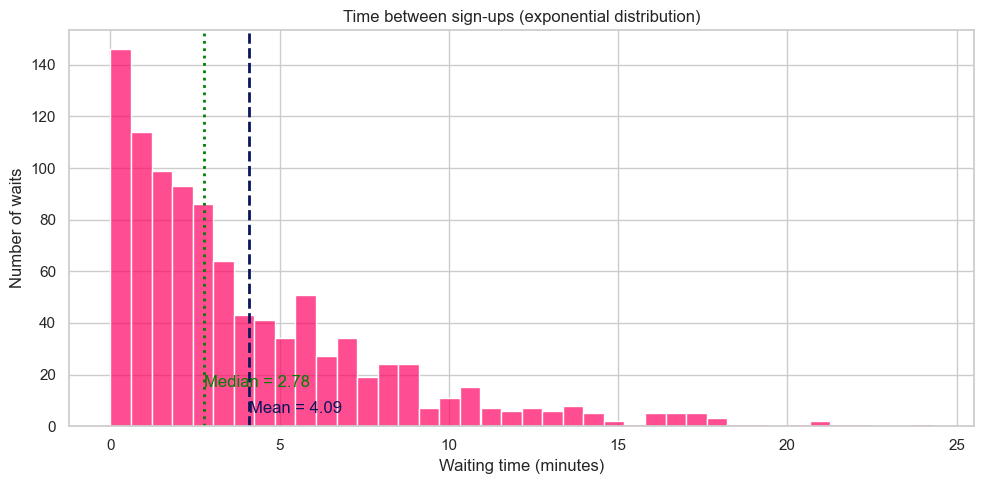

In [ ]:
# Your code here

## Task 5: Model support tickets with the Poisson distribution

The IT helpdesk receives an average of 5 support tickets per hour. Tickets arrive independently at a constant rate. The lecture taught you that this kind of count follows a Poisson distribution with parameter lambda equal to the mean rate.

### Instructions

This task uses **two code cells**.

**First code cell**, generate counts and check the Poisson signature:

1. Define the parameters: `lambda_rate = 5` and `n_hours = 1000`.
2. Generate the counts: `ticket_counts = np.random.poisson(lam=lambda_rate, size=n_hours)`. The `lam` argument is the average rate. Each draw is a non-negative integer.
3. Compute the sample mean and the sample variance:
   - `ticket_mean = ticket_counts.mean()`.
   - `ticket_variance = ticket_counts.var()`.
4. Print both with two decimal places, next to the theoretical value of `lambda_rate`. Both should land near 5: `print(f"Sample mean    : {ticket_mean:.2f}  (theory: {lambda_rate})")` and the same pattern for the variance.
5. Count and print how many hours had zero tickets:
   - `zero_hours = (ticket_counts == 0).sum()`.
   - `print(f"\nHours with zero tickets: {zero_hours} out of {n_hours}")`.

**Second code cell**, the histogram with one bin per integer:

1. Find the largest count in your data: `max_count = ticket_counts.max()`.
2. Build bin edges that are centered on each integer. The trick is to put the edges at half-integer values so each integer count gets its own bar:
   ```python
   bin_edges = np.arange(-0.5, max_count + 1.5, 1)
   ```
3. Open a figure: `fig, ax = plt.subplots(figsize=(10, 5))`.
4. Draw the histogram with these custom edges: `sns.histplot(x=ticket_counts, bins=bin_edges, color="#FE0162", alpha=0.7, ax=ax)`.
5. Add a dashed line at the sample mean and label it:
   - `ax.axvline(ticket_mean, color="#0B155B", linestyle="--", linewidth=2)`.
   - `ax.text(ticket_mean, 5, f"Mean = {ticket_mean:.2f}", color="#0B155B")`.
6. Set the title and axis labels (`Number of tickets per hour`, `Number of hours`).
7. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**Bin edges at half-integers.** For integer-valued data, the cleanest histogram puts each integer in the middle of its own bar. Edges at -0.5, 0.5, 1.5, 2.5, ... give every integer count its own bin and avoid two values sharing a bar.
</Note>


In [ ]:
# Your code here

Sample mean    : 5.15  (theory: 5)
Sample variance: 5.57  (theory: 5)

Hours with zero tickets: 9 out of 1000


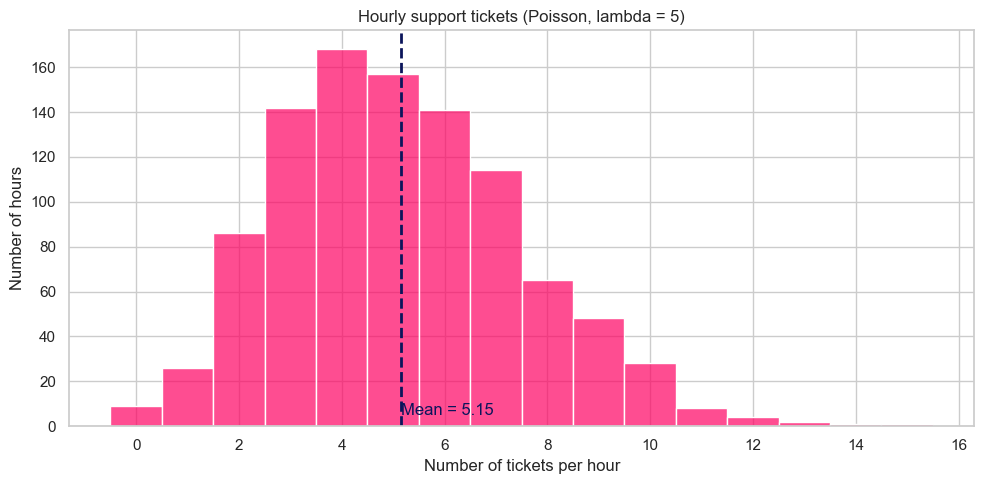

In [ ]:
# Your code here